# VERIX vs CertCF: synthetic-32 network grid

This notebook analyzes the Cartesian product of depths $D\in\{1,\ldots,5\}$ and widths $W\in\{16,32,64,128,256\}$. Every architecture uses the same 10 balanced queries. VERIX has a cumulative 120-second wall-clock budget per architecture/query traversal; timeout and witness coverage are therefore first-class outcomes rather than silently dropped failures.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'src'))

from notebooks.utils.verix_certcf import (
    completion_table, compute_synthetic32_diagnostics,
    load_synthetic32_results, method_summary,
    summarize_empirical_robustness, summarize_quality_metrics,
)

CONFIG_PATH = ROOT / 'configs/experiments/verix_certcf_synthetic32_grid.yaml'
RESULT_DIR = ROOT / 'results/verix_certcf_synthetic32_grid'
RECOMPUTE_DIAGNOSTICS = False
DEVICE = 'auto'

QUERIES, RUNNER_SUMMARY, MANIFEST = load_synthetic32_results(RESULT_DIR)
POINTS, ROBUSTNESS_CURVES, DIAGNOSTICS = compute_synthetic32_diagnostics(
    config_path=CONFIG_PATH, result_dir=RESULT_DIR, device=DEVICE,
    certified=True, certified_maximum=5.0, certified_steps=14,
    force=RECOMPUTE_DIAGNOSTICS,
)
METHODS = method_summary(QUERIES)
QUALITY = summarize_quality_metrics(POINTS)
EMPIRICAL = summarize_empirical_robustness(ROBUSTNESS_CURVES)
keys = ['architecture_id', 'depth', 'width', 'parameter_count', 'method']
GRID = METHODS.merge(QUALITY, on=keys, how='left').merge(
    EMPIRICAL, on=['architecture_id', 'method'], how='left'
)
GRID['method'] = GRID['method'].astype(str)
sns.set_theme(style='whitegrid', context='notebook')

## 1. Completion, timeout, and witness coverage

A timeout does not invalidate proven VERIX steps. Features unresolved when the cumulative budget expires remain in the explanation as `UNKNOWN`. Witness coverage is the fraction for which VERIX produced at least one canonically valid native witness. Because this experiment is binary, the common target is always the unique class opposite the source prediction; a missing VERIX witness remains a VeriX failure rather than preventing CertCF from running.

In [2]:
COMPLETION = completion_table(QUERIES, MANIFEST)
display(COMPLETION)

per_query = QUERIES.drop_duplicates(['architecture_id', 'query_index']).copy()
VERIX_STATUS = (
    per_query.groupby(['architecture_id', 'depth', 'width', 'parameter_count'], observed=True)
    .agg(
        queries=('query_index', 'count'),
        timeout_rate=('verix_query_timed_out', 'mean'),
        witness_coverage=('verix_witness_available', 'mean'),
        locally_minimal_rate=('verix_locally_minimal', 'mean'),
        mean_unknown_features=('verix_unknown_size', 'mean'),
        mean_valid_witnesses=('verix_valid_witness_count', 'mean'),
    ).reset_index()
)
display(VERIX_STATUS.style.format({
    'timeout_rate': '{:.1%}', 'witness_coverage': '{:.1%}',
    'locally_minimal_rate': '{:.1%}', 'mean_unknown_features': '{:.2f}',
    'mean_valid_witnesses': '{:.2f}',
}))

,architecture_id,method,rows,unique_queries,expected_queries,complete
0,depth_01_width_016,verix,10,10,10,True
1,depth_01_width_016,certcf,10,10,10,True
2,depth_01_width_032,verix,10,10,10,True
3,depth_01_width_032,certcf,10,10,10,True
4,depth_01_width_064,verix,10,10,10,True
5,depth_01_width_064,certcf,10,10,10,True
6,depth_01_width_128,verix,10,10,10,True
7,depth_01_width_128,certcf,10,10,10,True
8,depth_01_width_256,verix,10,10,10,True
9,depth_01_width_256,certcf,10,10,10,True


,architecture_id,depth,width,parameter_count,queries,timeout_rate,witness_coverage,locally_minimal_rate,mean_unknown_features,mean_valid_witnesses
0,depth_01_width_016,1,16,562,10,0.0%,100.0%,100.0%,0.00,8.40
1,depth_01_width_032,1,32,1122,10,0.0%,90.0%,100.0%,0.00,6.60
2,depth_01_width_064,1,64,2242,10,50.0%,60.0%,50.0%,5.10,5.30
3,depth_01_width_128,1,128,4482,10,100.0%,10.0%,0.0%,13.80,0.40
4,depth_01_width_256,1,256,8962,10,100.0%,0.0%,0.0%,16.60,0.00
5,depth_02_width_016,2,16,834,10,0.0%,90.0%,100.0%,0.00,8.10
6,depth_02_width_032,2,32,2178,10,60.0%,30.0%,40.0%,6.10,3.70
7,depth_02_width_064,2,64,6402,10,100.0%,10.0%,0.0%,17.30,0.20
8,depth_02_width_128,2,128,20994,10,100.0%,10.0%,0.0%,19.40,0.20
9,depth_02_width_256,2,256,74754,10,100.0%,0.0%,0.0%,21.70,0.00


## 2. Complete per-architecture metric table

Success rate uses target-eligible queries. Proximity, sparsity, on-manifoldness, empirical robustness, and certified radii use successful counterfactuals only. LOF is shown as $\log_{10}(\mathrm{LOF})$ (lower is better); the Isolation Forest score is higher for more typical points. No relative-proximity ratio is computed for this comparison.

In [3]:
TABLE = GRID.merge(
    VERIX_STATUS[['architecture_id', 'timeout_rate', 'witness_coverage', 'mean_unknown_features']],
    on='architecture_id', how='left',
)
columns = [
    'architecture_id', 'depth', 'width', 'parameter_count', 'method',
    'timeout_rate', 'witness_coverage', 'success_rate',
    'mean_l1', 'mean_l0', 'mean_log10_lof',
    'mean_isolation_forest_score', 'empirical_robustness_pct',
    'mean_certified_l1_radius', 'mean_certified_l2_radius',
    'mean_certified_linf_radius', 'mean_query_seconds',
    'offline_build_seconds', 'mean_unknown_features',
]
display(TABLE[columns].sort_values(['depth', 'width', 'method']).style.format({
    'timeout_rate': '{:.1%}', 'witness_coverage': '{:.1%}',
    'success_rate': '{:.1%}', 'mean_l1': '{:.3f}', 'mean_l0': '{:.2f}',
    'mean_log10_lof': '{:.3f}', 'mean_isolation_forest_score': '{:.3f}',
    'empirical_robustness_pct': '{:.1f}',
    'mean_certified_l1_radius': '{:.4f}',
    'mean_certified_l2_radius': '{:.4f}',
    'mean_certified_linf_radius': '{:.4f}',
    'mean_query_seconds': '{:.3f}', 'offline_build_seconds': '{:.1f}',
    'mean_unknown_features': '{:.2f}',
}))

,architecture_id,depth,width,parameter_count,method,timeout_rate,witness_coverage,success_rate,mean_l1,mean_l0,mean_log10_lof,mean_isolation_forest_score,empirical_robustness_pct,mean_certified_l1_radius,mean_certified_l2_radius,mean_certified_linf_radius,mean_query_seconds,offline_build_seconds,mean_unknown_features
1,depth_01_width_016,1,16,562,certcf,0.0%,100.0%,100.0%,23.796,20.20,0.016,-0.421,97.8,1.4873,0.6062,0.1294,0.143,14.0,0.00
0,depth_01_width_016,1,16,562,verix,0.0%,100.0%,100.0%,10.914,23.70,0.064,-0.454,56.0,0.0000,0.0000,0.0000,0.365,0.0,0.00
3,depth_01_width_032,1,32,1122,certcf,0.0%,90.0%,100.0%,23.941,20.90,0.008,-0.411,100.0,1.8906,0.7595,0.1624,0.136,14.6,0.00
2,depth_01_width_032,1,32,1122,verix,0.0%,90.0%,90.0%,11.480,25.22,0.064,-0.451,56.7,0.0000,0.0000,0.0000,9.275,0.0,0.00
5,depth_01_width_064,1,64,2242,certcf,50.0%,60.0%,100.0%,23.770,19.90,0.009,-0.414,100.0,1.6494,0.6637,0.1430,0.140,16.0,5.10
4,depth_01_width_064,1,64,2242,verix,50.0%,60.0%,60.0%,9.392,22.17,0.080,-0.468,57.3,0.0000,0.0000,0.0000,78.167,0.0,5.10
7,depth_01_width_128,1,128,4482,certcf,100.0%,10.0%,100.0%,24.362,20.60,0.008,-0.412,100.0,1.6730,0.6591,0.1421,0.134,16.8,13.80
6,depth_01_width_128,1,128,4482,verix,100.0%,10.0%,10.0%,9.350,20.00,0.111,-0.471,64.0,0.0000,0.0000,0.0000,120.536,0.0,13.80
9,depth_01_width_256,1,256,8962,certcf,100.0%,0.0%,100.0%,23.849,20.80,0.010,-0.413,100.0,1.6161,0.6099,0.1299,0.135,16.8,16.60
8,depth_01_width_256,1,256,8962,verix,100.0%,0.0%,0.0%,nan,nan,nan,nan,nan,nan,nan,nan,120.340,0.0,16.60


### 2.1 Shared-success comparison

The table above describes each method on all of its successful outputs. Since VERIX succeeds on a subset of the grid, its aggregate quality metrics are not directly comparable with CertCF's 250-query aggregates. The following table restricts both methods to the exact architecture/query pairs on which both return valid counterfactuals. Green highlights indicate the better value for each metric, with lower preferred for distance, sparsity, LOF, and online time, and higher preferred for Isolation Forest and robustness.

In [4]:
success_matrix = QUERIES.pivot_table(
    index=['architecture_id', 'query_index'], columns='method',
    values='success', aggfunc='first',
)
shared_keys = success_matrix[
    success_matrix.get('verix', False).fillna(False)
    & success_matrix.get('certcf', False).fillna(False)
].reset_index()[['architecture_id', 'query_index']]
shared_base = QUERIES.merge(shared_keys, on=['architecture_id', 'query_index'], how='inner')
shared_points = POINTS.merge(shared_keys, on=['architecture_id', 'query_index'], how='inner')
shared_robustness = ROBUSTNESS_CURVES.merge(shared_keys, on=['architecture_id', 'query_index'], how='inner')

SHARED = (
    shared_base.groupby('method', observed=True)
    .agg(
        shared_successes=('query_index', 'size'),
        mean_l1=('l1_distance', 'mean'), mean_l2=('l2_distance', 'mean'),
        mean_l0=('l0_changed', 'mean'), mean_online_seconds=('runtime_seconds', 'mean'),
    ).reset_index()
)
shared_quality = (
    shared_points.groupby('method', observed=True)
    .agg(
        mean_log10_lof=('log10_lof', 'mean'),
        mean_isolation_forest_score=('isolation_forest_score', 'mean'),
        mean_certified_l1_radius=('certified_l1_radius', 'mean'),
        mean_certified_l2_radius=('certified_l2_radius', 'mean'),
        mean_certified_linf_radius=('certified_linf_radius', 'mean'),
    ).reset_index()
)
shared_empirical = (
    shared_robustness.groupby('method', observed=True)
    .agg(empirical_robustness_pct=('empirical_target_rate', lambda x: 100 * x.mean()))
    .reset_index()
)
SHARED = SHARED.merge(shared_quality, on='method').merge(shared_empirical, on='method')
lower_is_better = ['mean_l1', 'mean_l2', 'mean_l0', 'mean_log10_lof', 'mean_online_seconds']
higher_is_better = [
    'mean_isolation_forest_score', 'empirical_robustness_pct',
    'mean_certified_l1_radius', 'mean_certified_l2_radius',
    'mean_certified_linf_radius',
]
display(
    SHARED.style
    .format({column: '{:.4f}' for column in lower_is_better + higher_is_better})
    .highlight_min(subset=lower_is_better, color='#d9ead3')
    .highlight_max(subset=higher_is_better, color='#d9ead3')
)

,method,shared_successes,mean_l1,mean_l2,mean_l0,mean_online_seconds,mean_log10_lof,mean_isolation_forest_score,mean_certified_l1_radius,mean_certified_l2_radius,mean_certified_linf_radius,empirical_robustness_pct
0,certcf,55,24.1805,6.1670,20.8364,0.1393,0.0086,-0.4161,1.7987,0.7186,0.1541,99.6000
1,verix,55,10.3827,2.2187,22.8000,34.4775,0.0639,-0.4537,0.0009,0.0003,0.0001,55.8545


## 3. Width $\times$ depth coverage heatmaps

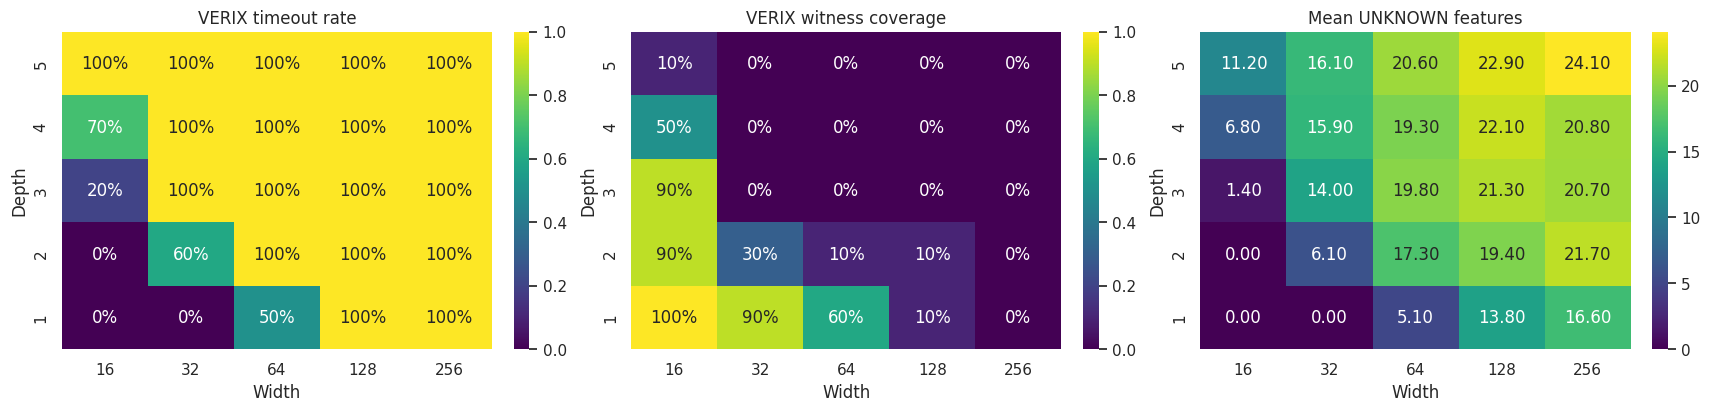

In [5]:
def heatmap(ax, frame, value, title, fmt='.2f', cmap='viridis', center=None):
    matrix = frame.pivot(index='depth', columns='width', values=value).sort_index(ascending=False)
    sns.heatmap(matrix, annot=True, fmt=fmt, cmap=cmap, center=center, ax=ax, cbar=True)
    ax.set_title(title)
    ax.set_xlabel('Width')
    ax.set_ylabel('Depth')

fig, axes = plt.subplots(1, 3, figsize=(17, 4), constrained_layout=True)
heatmap(axes[0], VERIX_STATUS, 'timeout_rate', 'VERIX timeout rate', fmt='.0%')
heatmap(axes[1], VERIX_STATUS, 'witness_coverage', 'VERIX witness coverage', fmt='.0%')
heatmap(axes[2], VERIX_STATUS, 'mean_unknown_features', 'Mean UNKNOWN features')
plt.show()

## 4. Quality, on-manifoldness, and robustness heatmaps

Each panel uses the same architecture grid and successful-query denominator. Empty cells mean that the method produced no successful counterfactuals for that combination.

<>:9: DeprecationWarning: invalid escape sequence '\l'
<>:14: DeprecationWarning: invalid escape sequence '\i'


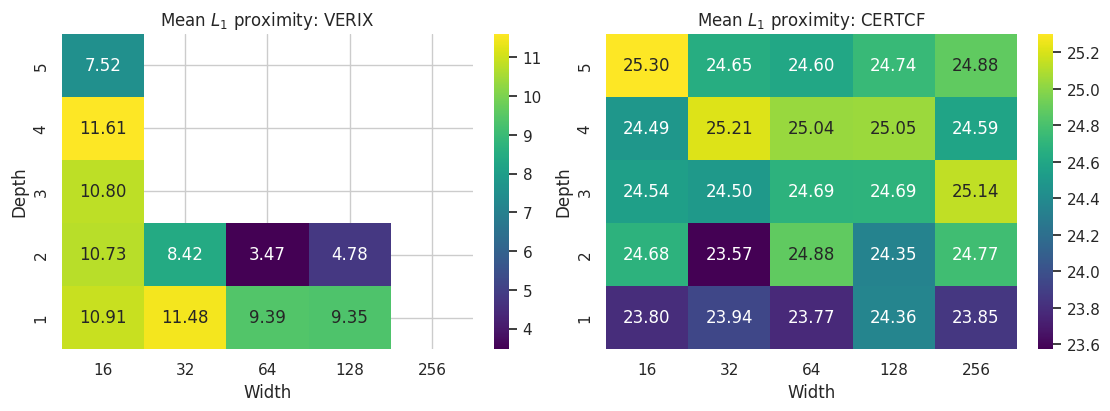

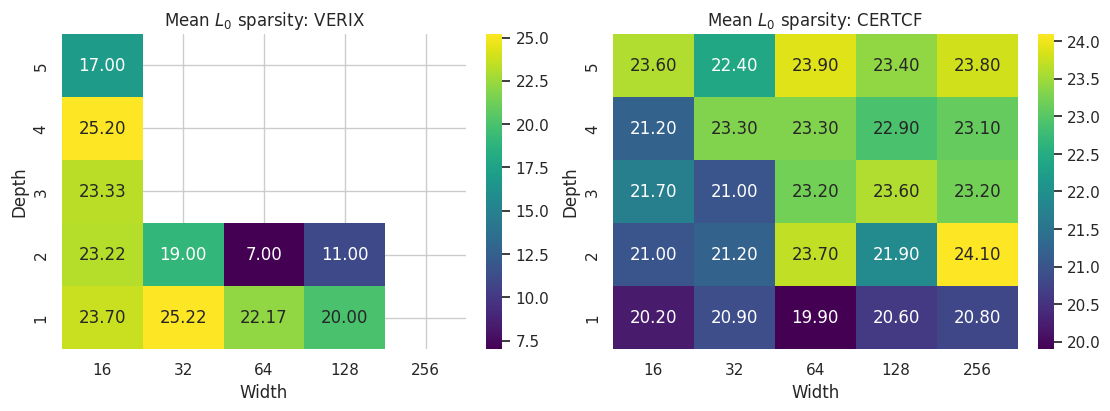

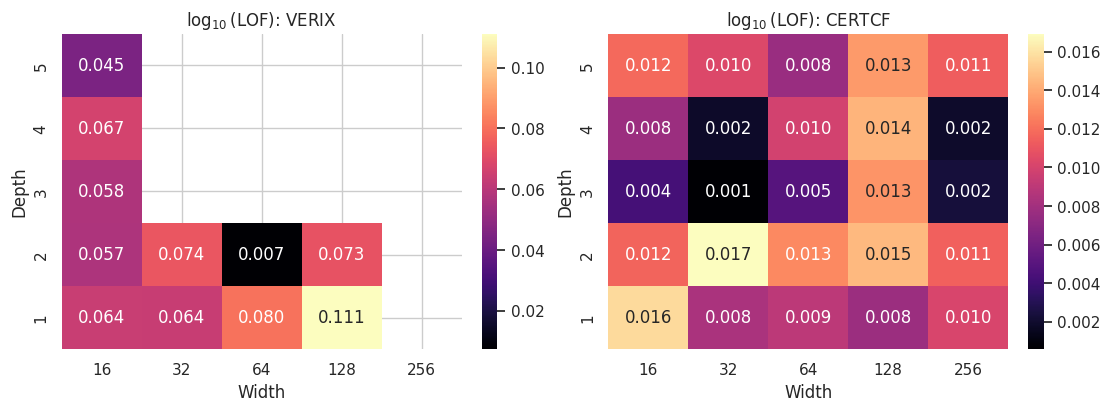

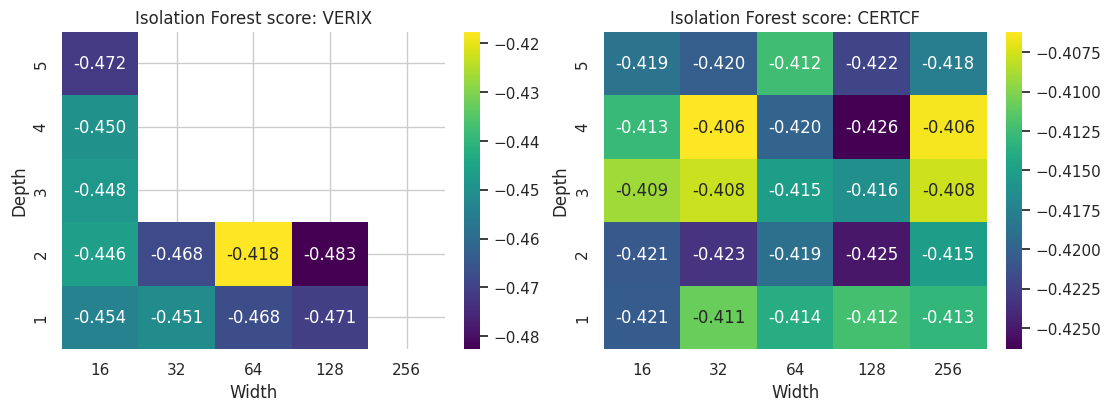

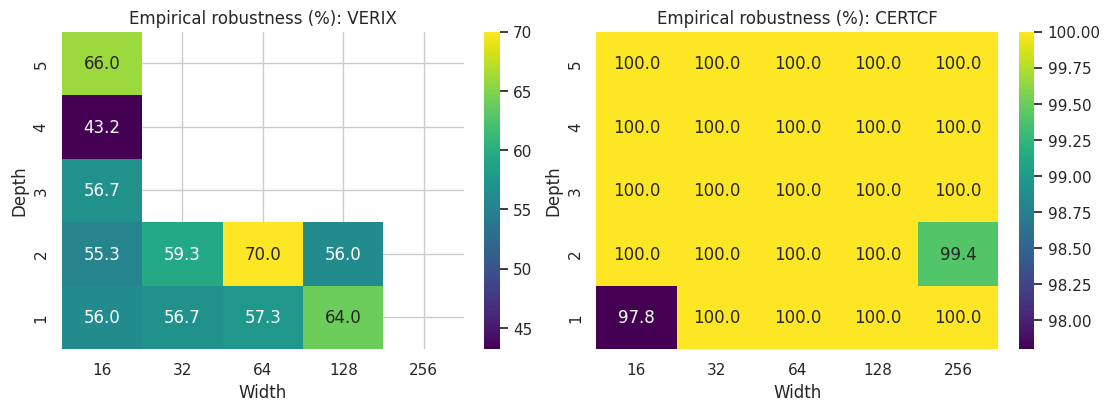

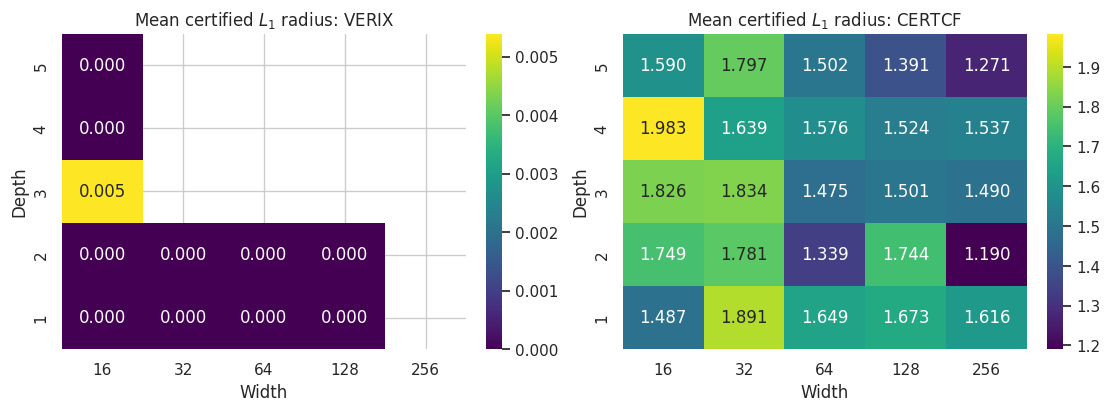

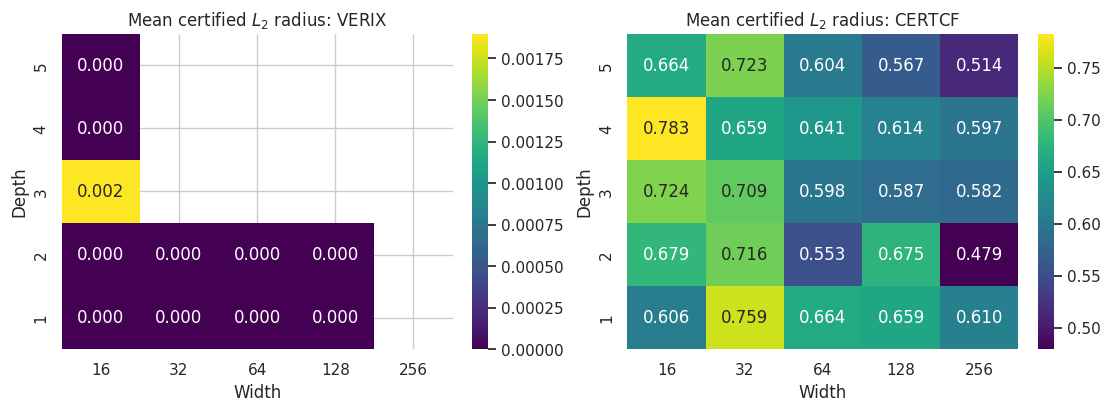

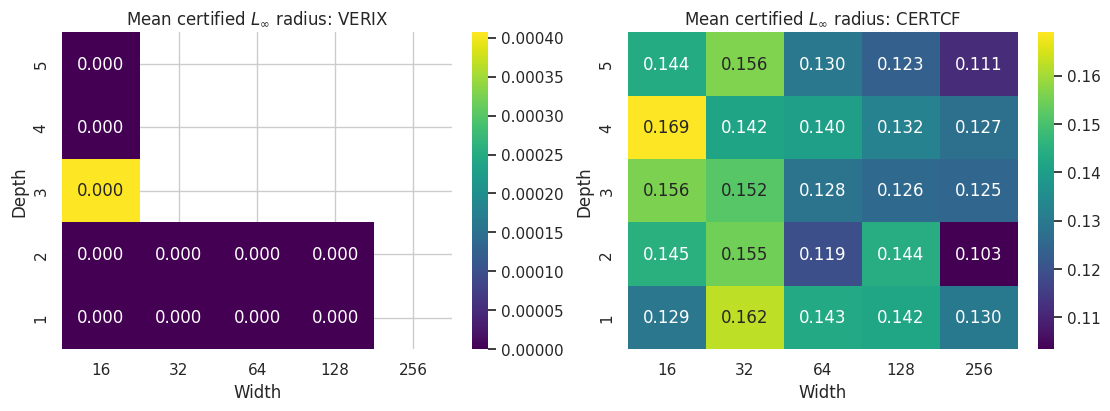

In [6]:
def method_heatmaps(value, label, fmt='.2f', cmap='viridis'):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    for ax, method in zip(axes, ['verix', 'certcf']):
        heatmap(ax, GRID[GRID['method'] == method], value, f'{label}: {method.upper()}', fmt=fmt, cmap=cmap)
    plt.show()

method_heatmaps('mean_l1', 'Mean $L_1$ proximity')
method_heatmaps('mean_l0', 'Mean $L_0$ sparsity')
method_heatmaps('mean_log10_lof', '$\log_{10}$(LOF)', fmt='.3f', cmap='magma')
method_heatmaps('mean_isolation_forest_score', 'Isolation Forest score', fmt='.3f')
method_heatmaps('empirical_robustness_pct', 'Empirical robustness (%)', fmt='.1f')
method_heatmaps('mean_certified_l1_radius', 'Mean certified $L_1$ radius', fmt='.3f')
method_heatmaps('mean_certified_l2_radius', 'Mean certified $L_2$ radius', fmt='.3f')
method_heatmaps('mean_certified_linf_radius', 'Mean certified $L_\infty$ radius', fmt='.3f')

## 5. Runtime and scaling

VERIX online time includes traversal scoring and formal feature checks up to the budget. CertCF online time excludes its one-time atlas construction. The atlas build panel is therefore shown separately.

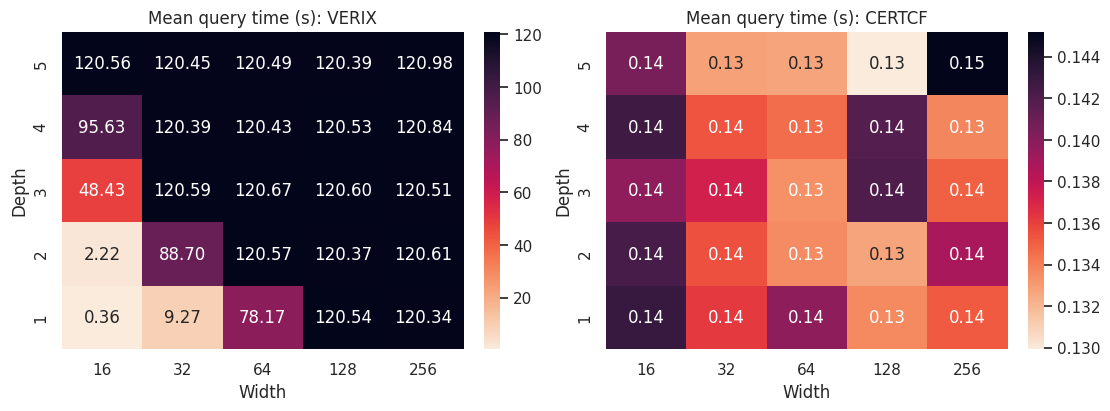

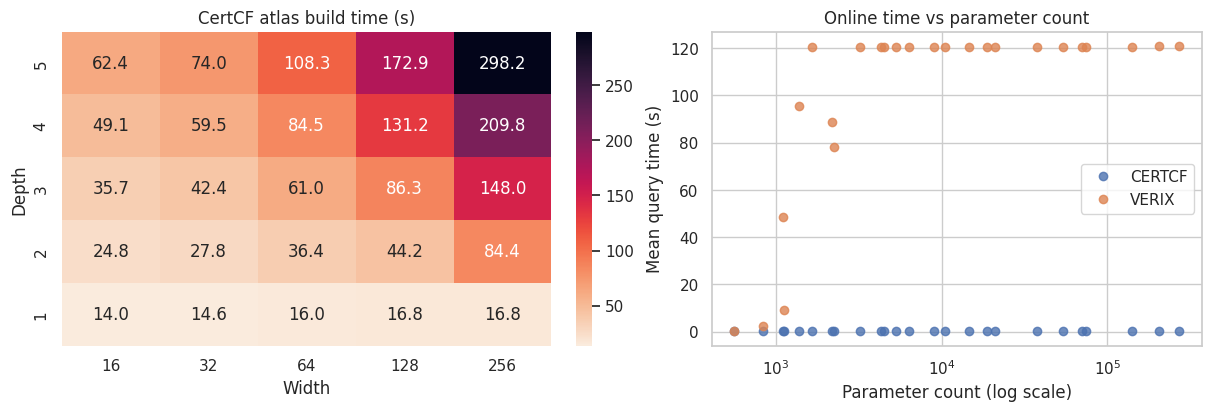

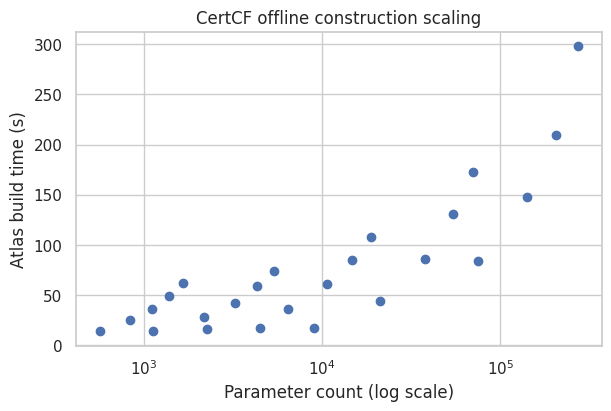

In [7]:
method_heatmaps('mean_query_seconds', 'Mean query time (s)', fmt='.2f', cmap='rocket_r')
certcf_grid = GRID[GRID['method'] == 'certcf'].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
heatmap(axes[0], certcf_grid, 'offline_build_seconds', 'CertCF atlas build time (s)', fmt='.1f', cmap='rocket_r')
for method, group in GRID.groupby('method', observed=True):
    axes[1].plot(group['parameter_count'], group['mean_query_seconds'], 'o', label=method.upper(), alpha=.8)
axes[1].set_xscale('log')
axes[1].set_xlabel('Parameter count (log scale)')
axes[1].set_ylabel('Mean query time (s)')
axes[1].set_title('Online time vs parameter count')
axes[1].legend()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.scatter(certcf_grid['parameter_count'], certcf_grid['offline_build_seconds'])
ax.set_xscale('log')
ax.set_xlabel('Parameter count (log scale)')
ax.set_ylabel('Atlas build time (s)')
ax.set_title('CertCF offline construction scaling')
plt.show()

## 6. Failures and resource limits

This audit table prevents timeout-limited cells from being mistaken for completed formal explanations. A VERIX witness found before timeout may still define a paired target, but `locally_minimal_rate < 1` or `mean_unknown_features > 0` indicates that the complete local-minimality claim was not established within the budget.

In [8]:
LIMITS = VERIX_STATUS[(VERIX_STATUS['timeout_rate'] > 0) | (VERIX_STATUS['witness_coverage'] < 1)].copy()
if LIMITS.empty:
    display(Markdown('No VERIX timeouts or missing native witnesses were observed.'))
else:
    display(LIMITS.sort_values(['depth', 'width']).style.format({
        'timeout_rate': '{:.1%}', 'witness_coverage': '{:.1%}',
        'locally_minimal_rate': '{:.1%}', 'mean_unknown_features': '{:.2f}',
    }))

failed = QUERIES[~QUERIES['success']].copy()
display(failed[[
    'architecture_id', 'query_index', 'method', 'paired_eligible',
    'verix_query_timed_out', 'verix_unknown_size',
]].sort_values(['architecture_id', 'query_index', 'method']))

,architecture_id,depth,width,parameter_count,queries,timeout_rate,witness_coverage,locally_minimal_rate,mean_unknown_features,mean_valid_witnesses
1,depth_01_width_032,1,32,1122,10,0.0%,90.0%,100.0%,0.00,6.600000
2,depth_01_width_064,1,64,2242,10,50.0%,60.0%,50.0%,5.10,5.300000
3,depth_01_width_128,1,128,4482,10,100.0%,10.0%,0.0%,13.80,0.400000
4,depth_01_width_256,1,256,8962,10,100.0%,0.0%,0.0%,16.60,0.000000
5,depth_02_width_016,2,16,834,10,0.0%,90.0%,100.0%,0.00,8.100000
6,depth_02_width_032,2,32,2178,10,60.0%,30.0%,40.0%,6.10,3.700000
7,depth_02_width_064,2,64,6402,10,100.0%,10.0%,0.0%,17.30,0.200000
8,depth_02_width_128,2,128,20994,10,100.0%,10.0%,0.0%,19.40,0.200000
9,depth_02_width_256,2,256,74754,10,100.0%,0.0%,0.0%,21.70,0.000000
10,depth_03_width_016,3,16,1106,10,20.0%,90.0%,80.0%,1.40,5.700000


,architecture_id,query_index,method,paired_eligible,verix_query_timed_out,verix_unknown_size
33,depth_01_width_032,877,verix,True,False,0
43,depth_01_width_064,165,verix,True,True,10
45,depth_01_width_064,229,verix,True,True,16
47,depth_01_width_064,271,verix,True,True,5
55,depth_01_width_064,929,verix,True,True,9
...,...,...,...,...,...,...
491,depth_05_width_256,786,verix,True,True,24
493,depth_05_width_256,877,verix,True,True,25
495,depth_05_width_256,929,verix,True,True,23
497,depth_05_width_256,956,verix,True,True,26


## 7. Interpretation caveats

- This is a deterministic one-seed study with 10 shared queries per architecture; it measures scaling behavior, not population uncertainty.
- Timeout rate and runtime censoring must be interpreted together: a timed-out VERIX runtime is a lower bound on the time needed to finish the traversal.
- VERIX and CertCF answer different formal questions. Native VERIX witnesses are verifier counterexamples encountered while minimizing an explanation; CertCF explicitly projects a query onto certified target-class regions.
- Certified $L_1$, $L_2$, and $L_\infty$ radii are recomputed post hoc with the same backward-LiRPA procedure for both methods.
- On-manifoldness diagnostics are empirical and do not constitute a formal data-manifold guarantee.